# Mini-GPT

> A complete GPT model's data flow passes through three stages: the input Embedding turns token IDs into vectors, the middle Transformer Blocks let vectors exchange information, and the output projection layer turns vectors back into predictions over the vocabulary. The Transformer Block from the previous section sits in the middle of this data flow — it takes `[batch, seq, d_model]` vectors, does Attention and FFN, and outputs vectors of the same shape.
>
> But the two ends of the Block are still disconnected. It cannot directly accept integer token IDs, nor can it output logits of vocabulary size. This section connects the input and output ends and runs the complete data flow.

Embedding is a `[vocab_size, d_model]` matrix; a lookup table is enough to turn integers into vectors. Self-Attention only looks at relationships between vectors and does not know who comes first, so a position encoding must be added after Embedding. After the Block finishes processing, a linear layer projects the result to `vocab_size` dimensions to get logits.

Suppose the vocabulary has 30 tokens and d_model=64. Given three token IDs `[5, 12, 3]`, after Embedding and position encoding they become `[3, 64]`; after passing through N layers of Blocks the shape is unchanged; finally they are projected to `[3, 30]` — each position outputs 30 scores, indicating the model's preference for the next token.

Let's first look at the overall structure of GPT, then implement each component step by step.

The core task of a language model is to predict the next token. Given the four characters of "today's weather", the model must judge that the probability of "very" appearing in the next position is higher than "apple". This process is one-directional — left to right, only looking at content that has already appeared.

The original Transformer was designed for machine translation as an Encoder-Decoder structure: the Encoder first reads the source language sentence, then the Decoder reads the Encoder's result through Cross-Attention and generates the target language word by word. A language model does not need this two-stage design — given the preceding context, directly predict the next token. The GPT series therefore keeps only the Decoder backbone, removing the Encoder and Cross-Attention. This structure is called Decoder-Only.

```text
GPT / Decoder-Only

Token IDs
  ↓
Token Embedding + Position Embedding
  ↓
Masked Self-Attention   ← can only see the current position and previous tokens
  ↓
Feed-Forward Network
  ↓
repeat many layers of Decoder Block
  ↓
LM Head
  ↓
predict next token
```

For comparison, the original Transformer is an Encoder-Decoder structure, commonly used for tasks like translation that require "read input first, then generate output":

```text
Original Transformer / Encoder-Decoder

Input sentence → Encoder → Encoder output
                         ↓
Target prefix → Decoder → Cross-Attention reads Encoder output
                         ↓
                      generate next token
```

Comparing the two diagrams: the original Transformer's Decoder has two types of Attention — Masked Self-Attention (looking at its own prefix) and Cross-Attention (looking at the Encoder's output). The GPT series only has Masked Self-Attention, because it is a pure generative model with no Encoder.

## Implementing MiniGPT from scratch

Next we implement MiniGPT from scratch, building it step by step with a small-scale configuration (vocab_size=30, d_model=64). Taking `batch_size=2, seq_len=3` as an example, see how the tensor shape changes along the way:

```text
Input (integer token ID)
  [[5, 12, 3],          ← sample 0
   [2, 7,  1]]          ← sample 1
  shape: [2, 3]
        ↓ Token Embedding       each ID looks up a 64-dim vector
        ↓ + Position Encoding   added with the same shape
  shape: [2, 3, 64]
        ↓ N layers of TransformerBlock keep shape unchanged
  shape: [2, 3, 64]
        ↓ LayerNorm + lm_head   project to vocabulary size
  shape: [2, 3, 30]
  Each position outputs 30 scores, corresponding to predictions for the 30 tokens in the vocabulary
```

The entire data flow has only two shape transitions: at the input end, integer IDs are expanded into d_model-dim vectors; at the output end, d_model-dim vectors are projected back to vocab_size; the N layers of Blocks in the middle always maintain `[batch, seq, d_model]` unchanged — this "shape preservation" is the prerequisite for being able to stack N layers.

In [1]:
import torch.nn as nn
import torch.nn.functional as F
import math


class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention; when a causal mask is passed, it becomes causal self-attention.

    Args:
        d_model: input/output dimension
        num_heads: number of attention heads
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # dimension of each head

        # Linear transforms for Q, K, V (combining num_heads into matrix operations)
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

        # Output projection
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        """
        Input:  x shape = [batch, seq_len, d_model]
        Output:   shape = [batch, seq_len, d_model]
        """
        batch_size, seq_len, _ = x.shape

        # 1. Linear transform + split into multiple heads
        #    [batch, seq_len, d_model] → [batch, num_heads, seq_len, d_k]
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Attention scores: Q @ K^T
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 3. Mask (e.g. set future positions to -inf)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # 4. Softmax
        weights = F.softmax(scores, dim=-1)

        # 5. Weighted sum
        attn_output = weights @ V  # [batch, num_heads, seq_len, d_k]

        # 6. Concatenate heads back and project
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)


class FeedForward(nn.Module):
    """FFN: two fully-connected layers, intermediate hidden dimension 4×d_model"""
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class TransformerBlock(nn.Module):
    """A Transformer decoder layer: Attention + FFN, each with residual + LayerNorm"""
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))  # x + Attention output, then LayerNorm
        x = self.norm2(x + self.ffn(x))              # x + FFN output, then LayerNorm
        return x

### Implementation of MiniGPT

The complete GPT data flow consists of four steps:

**Step 1: Token Embedding.** The input sequence is a set of integer token IDs, such as `[5, 12, 3]`. The integers themselves carry no semantic information; a lookup matrix of `[vocab_size, d_model]` is needed to map each ID to a d_model-dim vector.

**Step 2: Position Encoding.** The same token appearing at position 1 and position 10 may have different meanings. Self-Attention only looks at relationships between tokens and has no position information, so a position encoding must be added after Embedding to tell the model which position in the sequence each vector comes from.

**Step 3: Multiple layers of Transformer Block.** The data after adding Embedding and position encoding passes through N Transformer Blocks in sequence. Each Block does the same thing: let positions exchange information, then apply nonlinear processing. Stacking multiple layers lets information fuse layer by layer — shallow layers capture relationships between adjacent tokens, deeper layers capture more distant and abstract dependencies.

**Final step: output projection.** After N layers of Blocks, each position gets a d_model-dim vector. A linear layer finally projects it to vocabulary size vocab_size to get logits — the score of each position for every token in the vocabulary.

In [2]:
# Reuse the sinusoidal position encoding from the previous section
import torch
import torch.nn as nn
import math
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

class MiniGPT(nn.Module):
    """Mini GPT: Token Embedding → N layers of TransformerBlock → LayerNorm → project to vocabulary

    Assembly relationships (corresponding to previous sections):
        token_emb  — Token Embedding, turns integer IDs into vectors via lookup (notebook 03)
        pe         — sinusoidal position encoding, tells the model "this vector comes from position n" (notebook 04)
        blocks     — N layers of TransformerBlock, each does Attention + FFN + residual + LayerNorm (notebook 05)
        ln_final   — final LayerNorm
        lm_head    — linear layer, projects d_model-dim vectors to vocabulary size to get logits

    Args:
        vocab_size:   vocabulary size (number of token types)
        d_model:      dimension of each vector, also called hidden size
        num_heads:    number of heads in multi-head attention
        num_layers:   number of Transformer Block layers
        max_seq_len:  maximum sequence length (size of the position encoding table)
    """
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=4, max_seq_len=128):
        super().__init__()
        self.d_model = d_model

        # Input end: Token Embedding + Position Encoding
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)  # buffer does not participate in gradient updates but is saved/loaded with the model

        # Middle: N layers of TransformerBlock
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])

        # Output end: LayerNorm + linear projection
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)  # d_model → vocab_size

    def forward(self, x):
        # x: [batch, seq_len] — integer token IDs, e.g. [[5, 12, 3, 8], [2, 7, 1, 9]]
        batch_size, seq_len = x.shape

        # 1. Embedding: turn integer IDs into d_model-dim vectors, then add position encoding
        #    shape: [batch, seq_len] → [batch, seq_len, d_model]
        x = self.token_emb(x) + self.pe[:seq_len, :]

        # 2. Causal mask: lower triangular all-1 matrix
        #    mask[i, j] = 1 means position i can see position j
        #    because it is lower triangular, position i can only see j <= i (itself and previous tokens)
        #    shape: [seq_len, seq_len] → [1, 1, seq_len, seq_len] (broadcast to batch and heads)
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        mask = mask.view(1, 1, seq_len, seq_len)

        # 3. Pass through N layers of TransformerBlock in sequence, shape stays [batch, seq_len, d_model]
        for block in self.blocks:
            x = block(x, mask)

        # 4. Final LayerNorm + project to vocabulary size
        #    shape: [batch, seq_len, d_model] → [batch, seq_len, vocab_size]
        x = self.ln_final(x)
        return self.lm_head(x)

In [3]:
# Test MiniGPT: the model is untrained, logits are random, only check whether shape is right
import torch
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=64, num_heads=4, num_layers=2)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}, trainable: {trainable_params:,}")

# Forward pass: batch=2, seq_len=8
batch_input = torch.randint(0, vocab_size, (2, 8))
logits = model(batch_input)
print(f"\nInput: {batch_input.shape}  →  Output: {logits.shape}")
print(f"Output = [batch=2, seq=8, vocab={vocab_size}] → logits for each word at each position")
print(f"logits[0, 7, :5]: {logits[0, 7, :5].tolist()}  ← scores for sample 0 position 7 predicting the next token")

Read the values printed above and connect them to the concept in this cell.
Input: torch.Size([2, 8]) → Output: torch.Size([2, 8, 30])Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [4]:
# Follow the architecture diagram and run once: print shape at each step
import torch
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=32, num_heads=4, num_layers=2, max_seq_len=16)
idx = torch.randint(0, vocab_size, (2, 6))  # batch=2, seq_len=6

with torch.no_grad():
    # Step 1: Token Embedding lookup
    token_vec = model.token_emb(idx)     # [2, 6] → [2, 6, 32]
    # Take the first seq_len rows of the position encoding table
    pos_vec = model.pe[:idx.shape[1], :]  # [6, 32]
    # Add them to get vectors with position information
    x = token_vec + pos_vec               # [2, 6, 32]
    print(f"1. token + position: {x.shape}")

    # Step 2: build the causal mask (lower triangular matrix, 1=visible, 0=masked)
    mask = torch.tril(torch.ones(idx.shape[1], idx.shape[1]))  # [6, 6]
    mask = mask.view(1, 1, idx.shape[1], idx.shape[1])         # [1, 1, 6, 6]

    # Step 3: pass through each TransformerBlock (Attention + FFN + residual + LN)
    for block_id, block in enumerate(model.blocks, start=1):
        x = block(x, mask)  # [2, 6, 32] → [2, 6, 32], shape unchanged
        print(f"2.{block_id} after TransformerBlock: {x.shape}")

    # Step 4: LayerNorm + project to vocabulary
    x = model.ln_final(x)                # [2, 6, 32]
    logits = model.lm_head(x)            # [2, 6, 32] → [2, 6, 30]
    print(f"3. logits: {logits.shape}")

print("Key observation: the middle always stays at d_model dimensions; only the last step becomes vocab_size.")

1. token + position: torch.Size([2, 6, 32])Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.3. logits: torch.Size([2, 6, 30])Read the values printed above and connect them to the concept in this cell.

### Logits and predictions

The code from the previous section outputs a tensor called logits, with shape `[batch, seq, vocab_size]`. This section explains what it is.

logits are the raw scores output by the model. If the vocabulary has 30 tokens, then each position outputs 30 scores:

```text
logits[batch, position, token_id]
```

The higher the score, the more the model believes this token is suitable as the "next token". For example, if `logits[0, 7, 12] = 2.3` is the highest score at position 7, it means the model (under current parameters) tends to output the token with ID 12 after position 7.

During training, Cross-Entropy Loss is used to make the correct answer's score higher and the wrong answers' scores lower. During generation, softmax is applied to logits to get a probability distribution, then samples from it or takes the maximum value. These topics are covered in subsequent sections.

### Special Tokens

MiniGPT can now output logits, but in actual use, the model still needs some "boundary symbols" to mark the structure of the sequence.

For example: where does the sequence start, where does it end, and which positions are only used to pad the length. In some scenarios, the model also needs to distinguish between the "thinking process" and the "final answer". These special markers are collectively called special tokens:

```text
<BOS>       begin of sequence, marks the start of the sequence
<EOS>       end of sequence, marks the end of the sequence; generation stops when it is encountered
<PAD>       padding, used to pad the length, marks that this position is not real content
<think>     thinking start, marks that we are entering a thinking region
</think>    thinking end, marks that the thinking region has ended and the final answer follows
```

Note that `<think>` does not make the model automatically smarter. It is just a symbol — the model has to learn to use it correctly, and the training data must repeatedly show this format.

In [5]:
# Demo: adding new special tokens to Mini-GPT's vocabulary
base_vocab = {
    "user": 0,
    "assistant": 1,
    "answer": 2,
    "357": 3,
    "289": 4,
    "103173": 5,
}

special_tokens = ["<BOS>", "<EOS>", "<PAD>", "<think>", "</think>"]

vocab = base_vocab.copy()
for token in special_tokens:
    if token not in vocab:
        vocab[token] = len(vocab)

print("Special token IDs after addition:")
for token in special_tokens:
    print(f"  {token:8s} -> {vocab[token]}")

print()
print("Key observation: <think> and </think> now have independent IDs,")
print("so the model can treat them as boundary symbols rather than ordinary text fragments.")

Read the values printed above and connect them to the concept in this cell.  <BOS>    -> 6
  <EOS>    -> 7
  <PAD>    -> 8
  <think>  -> 9
  </think> -> 10

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [6]:
# Demo: what a training sample with <think> looks like
sample_tokens = [
    "<BOS>",
    "user",
    "357",
    "289",
    "assistant",
    "<think>",
    "357",
    "289",
    "103173",
    "</think>",
    "answer",
    "103173",
    "<EOS>",
]

sample_ids = [vocab[token] for token in sample_tokens]

print("Training sample tokens:")
print(sample_tokens)
print()
print("Training sample IDs:")
print(sample_ids)
print()
print("Key observation: only when this format appears in training data will the model learn when to start thinking and when to stop.")

Training sample token:['<BOS>', 'user', '357', '289', 'assistant', '<think>', '357', '289', '103173', '</think>', 'answer', '103173', '<EOS>']
Training sample ID:[6, 0, 3, 4, 1, 9, 3, 4, 5, 10, 2, 5, 7]

Read the values printed above and connect them to the concept in this cell.

After adding special tokens, the vocabulary grows. When the vocabulary grows, the Embedding table must also be expanded, because each token needs its own vector.

In [7]:
# Small matrix demo: why Embedding must expand after adding new tokens
import torch
import torch.nn as nn
old_vocab_size = len(base_vocab)
new_vocab_size = len(vocab)
d_model = 8

torch.manual_seed(42)
old_embedding = nn.Embedding(old_vocab_size, d_model)
new_embedding = nn.Embedding(new_vocab_size, d_model)

# Copy the old token vectors over; new token vectors keep their random initialization, which will be updated by later training
with torch.no_grad():
    new_embedding.weight[:old_vocab_size] = old_embedding.weight

print(f"Old vocabulary size: {old_vocab_size}")
print(f"New vocabulary size: {new_vocab_size}")
print(f"Embedding shape: {tuple(new_embedding.weight.shape)}")
print()
print("Key observation: after adding 5 special tokens, the Embedding also has 5 more rows.")
print("These new rows will only learn the real use of <think>, </think> through later training.")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## nanoGPT: from teaching version to engineering implementation

Up to here, we have implemented every component of GPT — Embedding, Attention, FFN, Transformer Block — from scratch. Stringing them together gives MiniGPT: vocabulary 30, hidden dimension 64, about 100K parameters. This scale is just right for running and verifying the data flow, and is sufficient as a teaching device.

But there is still a gap of orders of magnitude between a teaching device and a real model. The real GPT-2 Small has a vocabulary of 50257, hidden dimension 768, 12 layers of Blocks, and about 124M parameters — more than a thousand times MiniGPT. At this scale, merely assembling parts is not enough: how to initialize parameters for stability, how to implement Attention without blowing up memory, how to group the optimizer, and whether input and output embeddings should share weights are all problems that engineering implementation cannot avoid.

[nanoGPT](https://github.com/karpathy/nanoGPT), open-sourced by Karpathy (one of OpenAI's founding members, former Tesla AI director, who wrote a series of build-from-scratch neural network tutorials), is exactly the complete engineering implementation of GPT-2 Small: same parts, same data flow, just configured and engineered to real training-script standards. The code is only 300-something lines, with no fancy abstractions, and can be read line by line.

Next, let's look at the nanoGPT implementation together.

### From MiniGPT to nanoGPT

The first hurdle in reading nanoGPT code is naming — the identifiers it uses differ from the hand-written MiniGPT above, but what they do corresponds one to one. Put this mapping table up front and refer back to it whenever needed while reading the code:

| Teaching version | nanoGPT | Role |
|:---|:---|:---|
| `MiniGPT` | `GPT` | decoder-only language model |
| `TransformerBlock` | `Block` | one Transformer Block layer (Attention + MLP + residual + LayerNorm) |
| `MultiHeadAttention` | `CausalSelfAttention` | causal multi-head self-attention |
| `FeedForward` | `MLP` | two-layer fully-connected feed-forward network |
| `token_emb` | `transformer.wte` | token embedding lookup |
| `pe / position` | `transformer.wpe` | position embedding lookup |
| `lm_head` | `lm_head` | hidden state projected to vocabulary |

Structurally, nanoGPT has nothing new; it just reassembles the same components to industrial standards: finer parameter initialization, Attention accelerated with Flash Attention, input-output embedding shared via weight tying, and a parameter-grouped optimizer. Let's first get it running.

### Running nanoGPT

Don't rush to read the source — first actually run a forward pass of nanoGPT, and check whether its output shape is correct and whether the initial loss is close to the random level. After it runs through, do a few small experiments to observe how the model structure affects parameter count and running time. These concrete observations will become the handle for reading the source later.

**Run a forward pass first**

In [8]:
# Run nanoGPT's tiny configuration
from karpathy_models import NanoGPT, NanoGPTConfig

import torch
nano_config = NanoGPTConfig(
    block_size=16,
    vocab_size=64,
    n_layer=2,
    n_head=2,
    n_embd=32,
    dropout=0.0,
    bias=True,
)

torch.manual_seed(42)
nano_model = NanoGPT(nano_config)
nano_model.eval()

idx = torch.randint(0, nano_config.vocab_size, (2, 8))
targets = torch.randint(0, nano_config.vocab_size, (2, 8))

with torch.no_grad():
    nano_logits, nano_loss = nano_model(idx, targets)

print("=== nanoGPT tiny forward ===")
print(f"input shape:  {tuple(idx.shape)}")
print(f"logits shape: {tuple(nano_logits.shape)}")
print(f"loss:         {nano_loss.item():.4f}")
print(f"params:       {nano_model.get_num_params():,}")
print("Observation: logits are still [batch, seq, vocab_size].")

number of parameters: 0.03M
=== nanoGPT tiny forward ===
input shape:  (2, 8)
logits shape: (2, 8, 64)
loss:         4.1788
params:       27,520
Read the values printed above and connect them to the concept in this cell.

**Break down the parameter count of each component**

The total parameter count is a single number that doesn't show which components the parameters are spent on. Use PyTorch's built-in `named_children()` to list nanoGPT's top-level submodules and count each one's parameters. nanoGPT packs most components into a container called `transformer`, so we drill down one more level to look at its internals.

nanoGPT uses weight tying — `lm_head` and `transformer.wte` share the same weights. The statistics below count these weights only once, so `lm_head` alone shows 0; the precise meaning of weight tying is discussed in a dedicated section later.

In [9]:
# Break down nanoGPT's top-level components + parameter count inside the transformer
def count_params(module, seen=None):
    """Count module parameters; skip already-seen parameters when seen is passed (used to handle weight tying)"""
    if seen is None:
        seen = set()
    total = 0
    for p in module.parameters():
        if id(p) in seen:
            continue
        seen.add(id(p))
        total += p.numel()
    return total

# Top-level view: accumulate in named_children order, tied weights counted only once
print("=== nanoGPT top-level components (tied weights counted only once) ===")
seen = set()
for name, module in nano_model.named_children():
    print(f"{name:12s}  params={count_params(module, seen):,}")

# Transformer internal view: list the parameter count of each submodule in this container
print()
print("=== inside transformer ===")
for name, module in nano_model.transformer.named_children():
    print(f"{name:12s}  params={count_params(module):,}")

print()
print("Observation: most parameters are in transformer.h (multiple layers of Block).")
print("At the top-level view, lm_head shows 0 because it shares weights with wte (weight tying).")

Read the values printed above and connect them to the concept in this cell.transformer   params=28,032
lm_head       params=0

Read the values printed above and connect them to the concept in this cell.wte           params=2,048
wpe           params=512
drop          params=0
h             params=25,408
ln_f          params=64

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**A few structural and behavioral experiments**

The previous section only ran forward to verify the shape. Let's do a few more small experiments to observe how nanoGPT's structure affects parameter count, running time, and initial loss:

1. How does the parameter count change when the model gets deeper (more layers)?
2. How does forward time change as the sequence gets longer?
3. Is the loss of a randomly initialized model close to the random-guess level?

All these experiments run on **untrained** models — the goal is to observe the properties of the structure itself, not to see generation quality. Generation quality has to wait until pretraining is done.

number of parameters: 0.01M
number of parameters: 0.03M
number of parameters: 0.05M
number of parameters: 0.08M
n_layer=1: params=14,816
n_layer=2: params=27,520
n_layer=4: params=52,928
n_layer=6: params=78,336
Read the values printed above and connect them to the concept in this cell.

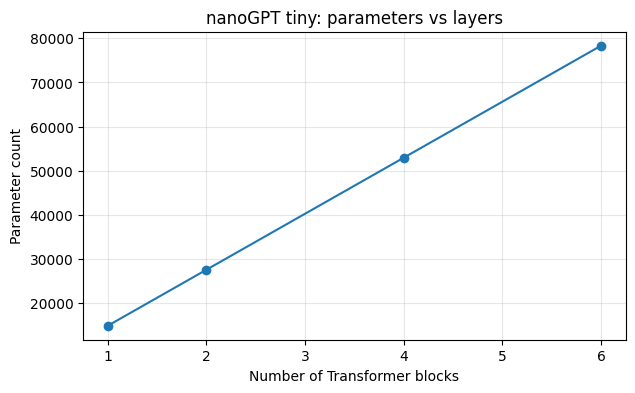

In [10]:
import matplotlib.pyplot as plt
# Experiment 1: how does nanoGPT's parameter count change as the number of layers increases
layer_counts = [1, 2, 4, 6]
nano_param_counts = []

for n_layer in layer_counts:
    cfg = NanoGPTConfig(
        block_size=16,
        vocab_size=64,
        n_layer=n_layer,
        n_head=2,
        n_embd=32,
        dropout=0.0,
        bias=True,
    )
    model = NanoGPT(cfg)
    nano_param_counts.append(model.get_num_params())

plt.figure(figsize=(7, 4))
plt.plot(layer_counts, nano_param_counts, marker="o")
plt.xlabel("Number of Transformer blocks")
plt.ylabel("Parameter count")
plt.title("nanoGPT tiny: parameters vs layers")
plt.grid(True, alpha=0.3)
plt.show()

for n_layer, params in zip(layer_counts, nano_param_counts):
    print(f"n_layer={n_layer}: params={params:,}")

print("Observation: the more layers, the more Attention and MLP parameters in each Block grow roughly linearly.")

seq_len= 4: avg_forward_time=0.110340s
seq_len= 8: avg_forward_time=0.111186s
seq_len=12: avg_forward_time=0.113103s
seq_len=16: avg_forward_time=0.118013s
Read the values printed above and connect them to the concept in this cell.

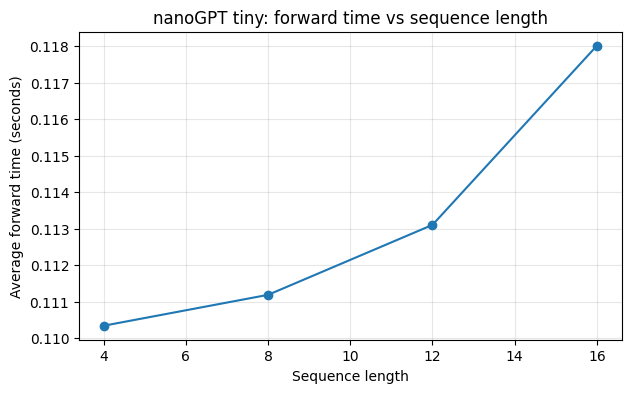

In [11]:
import matplotlib.pyplot as plt
import time
# Experiment 2: how does forward time change as sequence length increases
# Note: single runs on CPU fluctuate a lot, so each length is run multiple times and averaged.
import torch
def benchmark_forward(model, seq_len, repeats=20):
    sample = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    target = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    with torch.no_grad():
        model(sample, target)  # warmup
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(repeats):
            model(sample, target)
    elapsed = time.perf_counter() - start
    return elapsed / repeats

seq_lengths = [4, 8, 12, 16]
forward_times = []
for seq_len_value in seq_lengths:
    forward_times.append(benchmark_forward(nano_model, seq_len_value))

plt.figure(figsize=(7, 4))
plt.plot(seq_lengths, forward_times, marker="o")
plt.xlabel("Sequence length")
plt.ylabel("Average forward time (seconds)")
plt.title("nanoGPT tiny: forward time vs sequence length")
plt.grid(True, alpha=0.3)
plt.show()

for seq_len_value, seconds in zip(seq_lengths, forward_times):
    print(f"seq_len={seq_len_value:2d}: avg_forward_time={seconds:.6f}s")

print("Observation: Self-Attention has to look at pairwise relationships between tokens, so computation usually gets more expensive as the sequence grows.")

nanoGPT loss:       4.1190
random guess loss:  4.1589
Loss

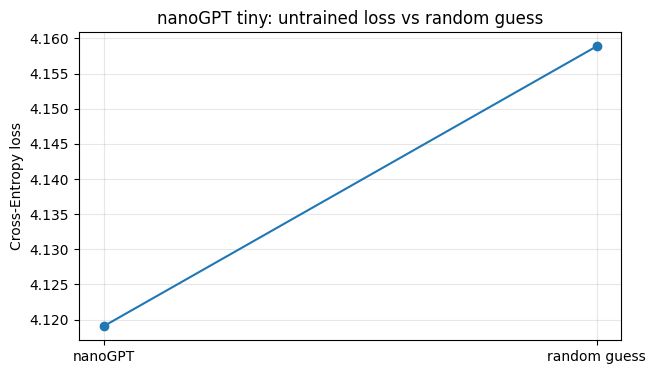

In [12]:
import matplotlib.pyplot as plt
# Experiment 3: nanoGPT's randomly initialized loss vs random-guess level
# The model is untrained, so the loss should be close to log(vocab_size).
import torch
import math
torch.manual_seed(123)
compare_idx = torch.randint(0, 64, (4, 12))
compare_targets = torch.randint(0, 64, (4, 12))

with torch.no_grad():
    compare_logits, compare_loss = nano_model(compare_idx, compare_targets)

random_guess_loss = math.log(64)
losses = [compare_loss.item(), random_guess_loss]
names = ["nanoGPT", "random guess"]

plt.figure(figsize=(7, 4))
plt.plot(names, losses, marker="o")
plt.ylabel("Cross-Entropy loss")
plt.title("nanoGPT tiny: untrained loss vs random guess")
plt.grid(True, alpha=0.3)
plt.show()

print(f"nanoGPT loss:       {compare_loss.item():.4f}")
print(f"random guess loss:  {random_guess_loss:.4f}")
print("Observation: an untrained GPT has loss close to the random-guess level. This is normal.")

### Reading the nanoGPT source code

After getting it running, go back and read the source. nanoGPT's `model.py` is only 300-something lines; it is recommended to read it from outside in: first look at the overall structure of the top-level `GPT` class, then trace the data flow of `GPT.forward`, and finally look at a few engineering details — where do parameters go, and why does Weight Tying make input and output embeddings share weights. These are all choices that can be seen in real GPT-2 training scripts.

**Reading order of model.py**

**Reading order of model.py**

When reading nanoGPT's [`model.py`](https://github.com/karpathy/nanoGPT/blob/master/model.py), the recommended order is:

```text
CausalSelfAttention   # self-attention with a causal mask
MLP                   # a small network that each token passes through independently
Block                 # Attention + MLP + Residual + LayerNorm
GPT                   # the assembly of embedding, blocks, ln_f, lm_head
GPT.forward           # the data flow of the whole model
```

These names can be directly matched with the hand-written versions above:

| Hand-written | nanoGPT code | Role |
|:---|:---|:---|
| `MultiHeadAttention` | `CausalSelfAttention` | multi-head causal self-attention |
| `FeedForward` | `MLP` | intra-token processing |
| `TransformerBlock` | `Block` | one Transformer decoder block layer |
| `MiniGPT` | `GPT` | the whole decoder-only model |
| `token_emb` | `transformer.wte` | token embedding table |
| `pe` / position | `transformer.wpe` | position embedding table |
| `lm_head` | `lm_head` | hidden state to vocab logits |

It is recommended to first read `model.py` to understand the model structure, then read the training script. Before the model structure is clear, the optimizer, checkpoint, and logging in the training loop can easily become noise.

**The main thread of `GPT.forward`**

`GPT.forward` is the function most worth reading first in nanoGPT. It compresses the entire GPT data flow into a single line:

```text
idx
  → wte(idx)                 # token embedding
  → wpe(pos)                 # position embedding
  → drop(tok_emb + pos_emb)
  → for block in h           # multiple layers of Transformer Block
  → ln_f
  → lm_head
  → logits / loss
```

This line follows the same data flow as the hand-written MiniGPT above. The difference lies in the specific configuration: nanoGPT uses the real parameters of GPT-2 Small, while the hand-written version shrinks the vocabulary, dimensions, and layer count drastically so it can run in a browser:

| Component | nanoGPT (GPT-2 Small) | Hand-written MiniGPT | Difference |
|:---|:---|:---|:---|
| `wte` / `token_emb` | `[50257, 768]` | `[30, 64]` | Vocabulary and dimension both shrunk; same principle |
| `wpe` / `pe` | `[1024, 768]`, learnable | `[128, 64]`, sinusoidal fixed | GPT-2 uses learnable position encoding; hand-written uses sinusoidal |
| `blocks` | 12 layers, 12 heads | 2-4 layers, 4 heads | Layer and head count shrunk; each layer has the same structure |
| `c_attn` | one linear layer computes Q/K/V at once | three separate linear layers W_Q/W_K/W_V | Combined computation is more efficient; same parameter count |
| `lm_head` | shares weights with `wte` (weight tying) | independent `nn.Linear` | GPT-2 saves parameters; hand-written keeps them separate for clarity |
| `dropout` | 0.1 (randomly drops during training) | none | Engineering code adds dropout to prevent overfitting |

What the engineering code adds on top includes some parts that do not belong to the model's main thread: optimizer configuration, checkpoint save/load, and sampling strategies during generation. These do not affect the data flow and can be skipped when reading `model.py`.

**Where do GPT-2 Small's parameters go**

MiniGPT uses a teaching-scale configuration (vocab_size=30, d_model=64, about 100K parameters). Now let's look at the parameter distribution of GPT-2 Small, a real model.

In [13]:
# Use GPT-2 Small's publicly available configuration directly, without depending on transformers
gpt2_config = {
    "vocab_size": 50257,
    "n_positions": 1024,
    "n_embd": 768,
    "n_layer": 12,
    "n_head": 12,
}

vocab_size = gpt2_config["vocab_size"]
n_positions = gpt2_config["n_positions"]
n_embd = gpt2_config["n_embd"]
n_layer = gpt2_config["n_layer"]
n_head = gpt2_config["n_head"]
d_ff = 4 * n_embd

print("=== GPT-2 Small configuration (public structural parameters) ===")
print(f"Vocabulary size:     {vocab_size}")
print(f"Hidden dimension:    {n_embd}")
print(f"Number of layers:    {n_layer}")
print(f"Number of heads:     {n_head}")
print(f"Max sequence length: {n_positions}")

Read the values printed above and connect them to the concept in this cell.Vocabulary size: 50257Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

GPT-2's parameters are mainly distributed across three parts: the Embedding tables, each Transformer Block layer, and the final LayerNorm. Let's compute the Embedding part first.

In [14]:
# Embedding layer parameters: Token Embedding + Position Embedding
# Token Embedding: a lookup matrix of shape [vocab_size, d_model]
#   each token ID corresponds to a row of d_model-dim vectors
wte_params = vocab_size * n_embd   # 50257 × 768

# Position Embedding: a lookup matrix of shape [n_positions, d_model]
#   each position corresponds to a row of d_model-dim vectors
wpe_params = n_positions * n_embd  # 1024 × 768

print(f"Token Embedding (wte):    {wte_params:>10,}")
print(f"Position Embedding (wpe): {wpe_params:>10,}")
print(f"Embedding total:          {wte_params + wpe_params:>10,}")
print()
print("Key observation: Embedding accounts for nearly 40% of GPT-2's parameters, but GPT-2 shares weights between wte and lm_head, so there is no extra cost.")

Token Embedding (wte):    38,597,376
Position Embedding (wpe):    786,432
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

Next, compute the parameters in each Transformer Block. One Block contains two LayerNorms, one Attention, and one MLP.

In [15]:
# ====== Parameters of each Transformer Block layer ======

# LayerNorm: learnable scale factor (weight) + shift (bias), each d_model in size
ln_params = 2 * n_embd  # 2 = weight + bias

# Attention parameters
# GPT-2 uses one linear layer c_attn to compute Q, K, V at once (rather than three separate linear layers)
# c_attn: input d_model → output 3×d_model (Q, K, V concatenated)
#   weights: [768, 2304] = n_embd × (3 × n_embd) parameters
#   bias:    [2304]      = 3 × n_embd parameters
attn_params = n_embd * (3 * n_embd) + (3 * n_embd)   # c_attn weights + bias
# c_proj: projects the multi-head concatenated result back to d_model
#   weights: [768, 768]  = n_embd × n_embd parameters
#   bias:    [768]       = n_embd parameters
attn_params += n_embd * n_embd + n_embd               # c_proj weights + bias

# MLP parameters: two fully-connected layers, first expand to 4× dimension then compress back
# fc1: d_model → 4×d_model
#   weights: [768, 3072] = n_embd × d_ff parameters
#   bias:    [3072]      = d_ff parameters
mlp_params = n_embd * d_ff + d_ff      # fc1 weights + bias
# fc2: 4×d_model → d_model
#   weights: [3072, 768] = d_ff × n_embd parameters
#   bias:    [768]       = n_embd parameters
mlp_params += d_ff * n_embd + n_embd   # fc2 weights + bias

# Each Block layer = LN1 + Attention + LN2 + MLP
layer_total = ln_params + attn_params + ln_params + mlp_params

print("=== Parameters of each Transformer Block layer ===")
print(f"LayerNorm 1:  {ln_params:>10,}")
print(f"Attention:    {attn_params:>10,}")
print(f"LayerNorm 2:  {ln_params:>10,}")
print(f"MLP:          {mlp_params:>10,}")
print(f"Per-layer total: {layer_total:>10,}")
print()
print("Key observation: MLP accounts for about 2/3 of each layer's parameters, Attention about 1/3.")

Read the values printed above and connect them to the concept in this cell.LayerNorm 1:       1,536
Attention:     2,362,368
LayerNorm 2:       1,536
MLP:           4,722,432
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

Finally, add all parts together to get the total parameter count of GPT-2 Small.

In [16]:
# Summary: Embedding + N layers of Block + final LayerNorm
ln_f_params = 2 * n_embd  # the final LayerNorm
total_unique_params = wte_params + wpe_params + n_layer * layer_total + ln_f_params

print("=== GPT-2 Small parameter summary ===")
print(f"Token Embedding (wte):       {wte_params:>10,}")
print(f"Position Embedding (wpe):    {wpe_params:>10,}")
print(f"{n_layer} layers of Block total:        {n_layer * layer_total:>10,}")
print(f"Final LayerNorm:             {ln_f_params:>10,}")
print(f"LM Head extra params:        {0:>10,}  ← GPT-2 shares weights with wte")
print(f"{'-' * 55}")
print(f"Total parameters (shared weights not double-counted): {total_unique_params:>10,}")
print()
print("Key observation: GPT-2 and MiniGPT share the same skeleton, but GPT-2 also uses learnable position encoding and weight sharing.")

Read the values printed above and connect them to the concept in this cell.Token Embedding (wte):       38,597,376
Position Embedding (wpe):       786,432
Read the values printed above and connect them to the concept in this cell.Final LayerNorm:                  1,536
Read the values printed above and connect them to the concept in this cell.-------------------------------------------------------
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

**Weight Tying: sharing weights between input and output**

In the earlier parameter statistics there was a line `LM Head extra params: 0`. The reason is that GPT-2 makes Token Embedding and the output projection layer share the same weight matrix, a practice called weight tying. The Embedding matrix has shape `[vocab_size, d_model]`, and the output projection goes in the opposite direction — mapping a hidden state back to vocabulary-sized logits. Weight tying directly reuses the transpose of the Embedding matrix as the output projection, without storing a separate copy of parameters.

This practice was first systematically justified by Press & Wolf (2016). The core observation is that each row of the output projection matrix corresponds to a scoring template for one token, and itself constitutes a kind of token representation — answering the same question as the input Embedding: "what is the semantics of this token". After sharing, the parameters are halved, and the same set of weights simultaneously receives gradients from both the input and output ends, equivalent to implicit multi-task learning. For GPT-2, weight tying saves 50257 × 768 ≈ 38.6M parameters.

The trend in modern large models is **no longer to share**. The table below lists the practices of several representative models:

| Model | Weight Tying | Notes |
|:---|:---|:---|
| GPT-2 | ✓ | saves parameters |
| LLaMA 3.2 1B / 3B | ✓ | small models save parameters |
| LLaMA 3 / 3.1 8B+ | ✗ | independent weights |
| Qwen2.5 ≤ 3B | ✓ | small models save parameters |
| Qwen2.5 ≥ 7B | ✗ | independent weights |
| Qwen3 (all series) | ✗ | all independent |
| DeepSeek-V3 | ✗ | independent weights |

The dividing line lies in parameter scale. Small models (≤ 3B) use weight tying to save parameters; large models (≥ 7B) tend to let input and output each learn their optimal representations. For DeepSeek-V3, keeping them separate costs about 1.85B more parameters, which is negligible relative to the 671B total.

In [17]:
# Comparison: the effect of Weight Tying on parameter count
demo_vocab = 100
demo_d = 64

# Not shared: wte and lm_head are each independent
wte_only = demo_vocab * demo_d      # Token Embedding
lm_head_only = demo_vocab * demo_d  # Output projection

# Shared: only one copy stored
tied = demo_vocab * demo_d

print("=== Weight Tying parameter savings (vocab=100, d=64) ===")
print(f"Not shared: wte {wte_only:,} + lm_head {lm_head_only:,} = {wte_only + lm_head_only:,}")
print(f"Shared:     only store {tied:,} (saves 50%)")
print()

# GPT-2's actual numbers
print("=== GPT-2's actual numbers ===")
print(f"wte parameters:  {vocab_size * n_embd:,}")
print(f"If lm_head were independent: extra {vocab_size * n_embd:,}")
print(f"After weight tying: lm_head extra 0, saves ~{vocab_size * n_embd / 1e6:.0f}M parameters")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

### Pretraining nanoGPT

Up to now we have only run forward; the model still has random weights. Next, let's train nanoGPT end to end.

What we do here is **pretraining**: take a piece of raw text and let the model learn to "continue writing" — given the preceding context, predict the next character. The model does not learn instructions, does not learn conversation, does not learn value judgments; it only learns the most basic statistical patterns of language. Modern large models go through SFT (instruction fine-tuning) and RLHF (reinforcement learning from human feedback) after pretraining to become assistants like ChatGPT, but that is a Part 2 topic; this section only focuses on pretraining itself.

The cost of pretraining grows quickly with scale. Real GPT-2 pretraining uses OpenWebText (tens of GB of corpus) and runs for several days on 8 V100s. The teaching scenario swaps in Karpathy's tiny shakespeare — a piece of about 1MB of Shakespeare text, character-level segmented, with a vocabulary of only 65 characters. After a few hundred steps of training on CPU, you can already see the model gradually turn from gibberish into something resembling English.

**Data preparation**

In [18]:
# Download tiny shakespeare (about 1MB, character-level corpus)
import urllib.request
import os

data_dir = "data/shakespeare_char"
os.makedirs(data_dir, exist_ok=True)
input_path = os.path.join(data_dir, "input.txt")

if not os.path.exists(input_path):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, input_path)

with open(input_path) as f:
    text = f.read()

print(f"Corpus length: {len(text):,} characters")
print(f"First 80 characters preview:")
print(repr(text[:80]))

# Character-level vocabulary: each character is one token
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"\nVocabulary size: {vocab_size}")
print(f"Vocabulary contents: {''.join(chars)}")

# Mapping between characters and integer IDs
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(f"\nEncoding example: 'ROMEO:' → {encode('ROMEO:')}")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.'

Vocabulary size: 65Vocabulary items: !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Read the values printed above and connect them to the concept in this cell.

The data needs to be split into two parts: 90% for training, 10% for validation. The validation set does not participate in training; it is only used to check whether the model is merely memorizing the training set.

During training, each batch is drawn by randomly selecting `batch_size` starting points, and from each starting point taking `block_size + 1` consecutive characters — the first `block_size` as input x, and the same window shifted by one as target y. Each position in y is the "next character" of the corresponding position in x, so the model learns "given the preceding context, predict the next character".

In [19]:
import numpy as np
import torch

# Split train / val (90% / 10%)
n = len(text)
train_ids = np.array(encode(text[:int(n * 0.9)]), dtype=np.uint16)
val_ids = np.array(encode(text[int(n * 0.9):]), dtype=np.uint16)
print(f"Training set: {len(train_ids):,} characters")
print(f"Validation set: {len(val_ids):,} characters")

# Training configuration (small model, runs on CPU)
block_size = 64       # context length per sample
batch_size = 32       # number of samples per batch
device = "cpu"

def get_batch(split):
    """Randomly draw a batch (x, y) from train or val"""
    data = train_ids if split == "train" else val_ids
    # Randomly select batch_size starting points, ensuring block_size+1 characters are available afterwards
    ix = np.random.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64)) for i in ix])
    return x, y

xb, yb = get_batch("train")
print(f"\nbatch x: {tuple(xb.shape)}  y: {tuple(yb.shape)}")
print(f"x[0] first 10 character IDs: {xb[0][:10].tolist()}")
print(f"Corresponding text: {decode(xb[0][:10].tolist())}")
print(f"\nKey observation: y is x shifted by one position — position i of y is position i+1 of x. The model is learning to 'predict the next character'.")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
batch x: (32, 64)  y: (32, 64)
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

**Training loop**

The core of the training loop is a four-step cycle: draw a batch → forward to compute loss → backward to compute gradients → optimizer updates weights.

nanoGPT uses the AdamW optimizer (Adam with weight decay). Paired with two engineering tricks: gradient clipping (`clip_grad_norm`) to prevent loss from suddenly exploding, and a learning rate of 1e-3 (small models can go a bit higher; large models usually use 3e-4).

Just watching the training loss go down is not enough — it only shows that the model is fitting the training set, not that the learned patterns also hold on new data. So every 100 steps, stop and estimate a validation loss as a monitoring signal during pretraining. How well the model ultimately learns has to wait until after training, when it is evaluated in a more comprehensive way — that is the topic of the next section.

In [20]:
import torch
from karpathy_models import NanoGPT, NanoGPTConfig

# Rebuild a small model with the char-level vocabulary (65)
train_config = NanoGPTConfig(
    block_size=block_size,
    vocab_size=vocab_size,
    n_layer=2,
    n_head=2,
    n_embd=64,
    dropout=0.0,
    bias=True,
)

torch.manual_seed(42)
train_model = NanoGPT(train_config).to(device)
print(f"Model parameter count: {train_model.get_num_params():,}")

optimizer = torch.optim.AdamW(train_model.parameters(), lr=1e-3, weight_decay=0.1)


@torch.no_grad()
def quick_val_loss(model, eval_iters=20):
    """Quickly estimate a validation loss: draw several batches from val and average"""
    model.eval()
    losses = []
    for _ in range(eval_iters):
        xb, yb = get_batch("val")
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


# Train for 500 steps, print training loss + validation loss every 100 steps
max_iters = 500
eval_interval = 100
history = []

train_model.train()
for it in range(max_iters):
    xb, yb = get_batch("train")
    logits, loss = train_model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(train_model.parameters(), 1.0)
    optimizer.step()

    if it % eval_interval == 0 or it == max_iters - 1:
        vl = quick_val_loss(train_model)
        history.append((it, loss.item(), vl))
        print(f"step {it:4d}/{max_iters}  train_loss {loss.item():.4f}  val_loss {vl:.4f}")

print(f"\nKey observation: val_loss drops from ~4.17 (random level log({vocab_size})={np.log(vocab_size):.2f}) to ~2.25,")
print("indicating the model is learning the statistical patterns between characters. But what exactly 2.25 means in terms of how much the model 'understands' has to be answered by the evaluation later.")

number of parameters: 0.10M
Read the values printed above and connect them to the concept in this cell.step    0/500  train_loss 4.1917  val_loss 4.0207
step  100/500  train_loss 2.5681  val_loss 2.5904
step  200/500  train_loss 2.4609  val_loss 2.4813
step  300/500  train_loss 2.4205  val_loss 2.4144
step  400/500  train_loss 2.2786  val_loss 2.3319
step  499/500  train_loss 2.2472  val_loss 2.2906

LossRead the values printed above and connect them to the concept in this cell.

### Looking at the results after training

Pretraining is done; val loss dropped from 4.17 to 2.25. But loss is an abstract number; looking at it alone cannot tell what the model actually learned. Let's check from three angles:

1. **The absolute level of validation loss** — compare it with random guessing to see how far the model is from "knowing nothing"
2. **Let the model write a passage** — eyeball whether the generated content looks like Shakespeare
3. **Pose multiple-choice questions** — given a context, let the model pick one of several candidate continuations, and count the accuracy

The first two are intuitive impressions; the third is a quantitative metric. The three angles complement each other and are much more comprehensive than looking at loss alone.

**The absolute level of validation loss**

First angle: run both the training loss and validation loss and compare them against the random-guess level. The training loss reflects how well the model performs on data it has seen, and the validation loss reflects generalization on new data — both are compared against the `log(vocab_size)` "knows nothing" baseline to see how far the model has come.

During validation, dropout is turned off and gradients are not needed (`torch.no_grad()`); sampling multiple times and averaging gives a more stable loss estimate.

In [21]:
@torch.no_grad()
def estimate_loss(model, split, eval_iters=50):
    """Sample multiple times and average for a more stable loss estimate"""
    model.eval()
    losses = []
    for _ in range(eval_iters):
        xb, yb = get_batch(split)
        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

train_loss = estimate_loss(train_model, "train")
val_loss = estimate_loss(train_model, "val")

import math
print(f"Training loss: {train_loss:.4f}")
print(f"Validation loss: {val_loss:.4f}")
print(f"Random baseline loss (log({vocab_size})): {math.log(vocab_size):.4f}")
print(f"\nKey observation: it is normal for the validation loss to be slightly higher than the training loss — the model performs slightly better on data it has seen.")
print("If the validation loss is far higher than the training loss (e.g. more than 0.5 apart), that is overfitting; you should reduce the number of training steps or add dropout.")

training loss: 2.2761LossLoss
LossLoss

**Let the model write a passage**

The first angle is to directly let the model continue writing. Generation is autoregressive: given a starting prompt, predict the next character each time, append it to the end of the sequence, then predict the next one, and loop a number of times.

The core question at each step is: how do we pick the next character from the probability distribution the model outputs? The two most naive approaches both have flaws —

- **Greedy decoding**: always pick the one with the highest probability. The result is completely deterministic, but generation easily falls into repetitive loops.
- **Sampling from the raw distribution**: draw randomly according to the model's output probabilities. The result is diverse, but occasionally a very-low-probability, unreasonable character gets drawn.

Actual generation finds a balance between the two, commonly using two knobs. Let's explain with a concrete example — suppose the vocabulary has only 5 characters A/B/C/D/E, and the model's logits for the next character are `[0.5, 1.0, 2.5, 3.0, 0.2]`; D has the highest logit, so the model most believes the next one is D.

**temperature adjusts the distribution shape**. The logits the model finally outputs have to go through softmax to become probabilities. What temperature does is divide the logits by a number $T$ before softmax:

$$
p_i = \frac{\exp(\text{logit}_i / T)}{\sum_j \exp(\text{logit}_j / T)}
$$

Intuitively: dividing by a number less than 1 is equivalent to magnifying the gaps between logits, making the softmax output sharper; dividing by a number greater than 1 is equivalent to shrinking the gaps, making the output flatter.

- $T = 1$: distribution unchanged
- $T < 1$: distribution sharper → generation more deterministic, more repetitive. When $T \to 0$ it degenerates to greedy
- $T > 1$: distribution flatter → generation more random. When $T \to \infty$ it degenerates to uniform sampling

During generation, $T \in [0.7, 1.0]$ is usually taken. The demo below plots the probability distribution of this set of logits under $T = 0.5 / 1.0 / 2.0$ as bar charts, so you can see what "sharp" and "flat" look like — for the same set of logits, under T=0.5 D's probability is pulled to 0.72, while under T=2.0 all 5 tokens' probabilities are compressed into the 0.10~0.30 range.

**top_k adjusts the candidate range**. The approach is to keep only the $k$ highest-probability tokens, discard all the rest, then sample among the remaining $k$ according to (re-normalized) probabilities. Intuitively: although the model assigns a probability to every token, the token ranked 200th is probably meaningless even if drawn. top_k cuts off this long-tail noise and forces the model to choose from a reasonable small pool.

Continuing with the example above, top_k=2 means keeping only D (logit 3.0) and C (logit 2.5); A/B/E are all discarded — when sampling, it will always only pick between D and C, and A/B/E in the long tail will never appear again.

- $k = 1$: degenerates to greedy
- $k = $ vocab_size: equivalent to no filtering
- Models with large vocabularies commonly use $k = 40 \sim 50$

The two are often used together: first use top_k to cut off the long tail, then use temperature to adjust the sharpness of the remaining distribution.

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

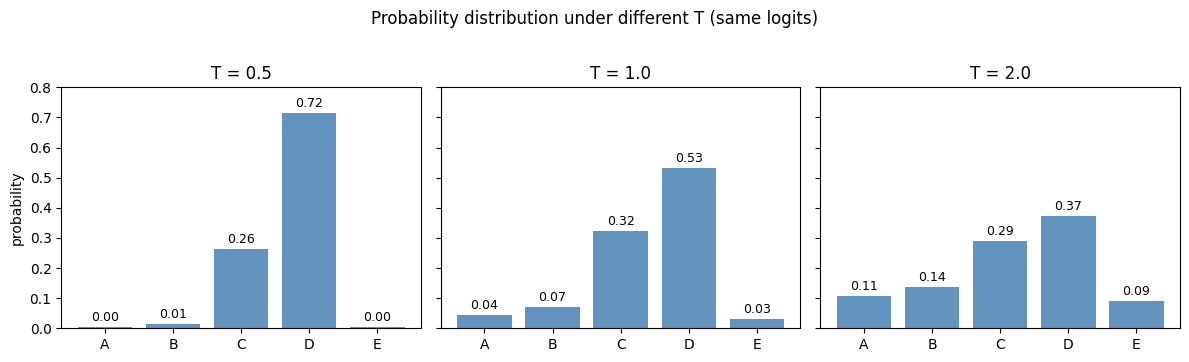

In [22]:
# Plot the probability distribution of the logits above under different T values
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Raw logits the model outputs for 5 characters; D is the most likely next character
logits = torch.tensor([0.5, 1.0, 2.5, 3.0, 0.2])
labels = ['A', 'B', 'C', 'D', 'E']
print(f"Raw logits: {dict(zip(labels, logits.tolist()))}")
print()

# Compare the same logits across three T values
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, T in zip(axes, [0.5, 1.0, 2.0]):
    probs = F.softmax(logits / T, dim=-1)
    ax.bar(labels, probs.tolist(), color='steelblue', alpha=0.85)
    ax.set_title(f"T = {T}")
    ax.set_ylim(0, 0.8)
    if ax is axes[0]:
        ax.set_ylabel("probability")
    # Label the number on top of each bar
    for i, p in enumerate(probs.tolist()):
        ax.text(i, p + 0.02, f"{p:.2f}", ha='center', fontsize=9)
plt.suptitle("Probability distribution under different T (same logits)", y=1.02)
plt.tight_layout()
plt.show()

print("Observation: under T=0.5 D's probability is pulled to 0.72, A/B/E nearly 0 → the model is very confident")
print("     under T=2.0 all 5 tokens' probabilities cluster in the 0.10~0.30 range → the model is very hesitant")
print()

# top_k filtering demo
print("=== top_k filtering (k=2) ===")
v, top_idx = torch.topk(logits, 2)
kept = [labels[i] for i in top_idx.tolist()]
dropped = [labels[i] for i in range(5) if i not in top_idx.tolist()]
print(f"Raw logits:    {dict(zip(labels, logits.tolist()))}")
print(f"Keep top 2:    {kept} (logits {v.tolist()})")
print(f"Discarded:     {dropped}")
print()
print("Sampling only draws between D and C by probability; A/B/E in the long tail will never be picked.")
print("Combining top_k and temperature:")
print("  top_k=2 + T=0.5: D is almost always picked (after keeping, D is ~0.62 after normalization)")
print("  top_k=2 + T=2.0: D and C are roughly 50/50 (the gap is flattened)")

In [23]:
import torch.nn.functional as F


@torch.no_grad()
def generate(model, prompt, max_new_tokens=200, temperature=0.8, top_k=None):
    """Autoregressively generate text starting from a prompt

    temperature: sharpness of the distribution; smaller is more deterministic
    top_k: sample only from the top-k highest-probability tokens; None means no restriction
    """
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature

        if top_k is not None:
            # Keep only the top_k highest-probability tokens, set the rest to -inf
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float("-Inf")

        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, idx_next], dim=1)

    return decode(idx[0].tolist())


# Like train_gpt2.py: continue from the same prompt multiple times to see the diversity of sampling
print("=== Generation 1 (prompt: 'ROMEO:', top_k=10, temperature=0.8) ===")
for i in range(3):
    print(f"--- sample {i+1} ---")
    print(generate(train_model, "ROMEO:", max_new_tokens=120, temperature=0.8, top_k=10))
    print()

print("=== Generation 2 (prompt: 'To be, or', temperature=0.5, no top_k) ===")
print(generate(train_model, "To be, or", max_new_tokens=120, temperature=0.5))

print("\nKey observation: the model has only been trained for a few hundred steps, but it can already spell out English-like words and scattered sentence structures.")
print("After a few thousand more steps, generation quality will approach real Shakespearean style — that is exactly what the train_shakespeare_char configuration in the nanoGPT repo does.")

Read the values printed above and connect them to the concept in this cell.--- sample 1 ---
ROMEO:
Fll and his thit the theared than so heer mes.

OLICESTUS:
MAnd that wisers ot havore elist, tup than an,
The it at ang

--- sample 2 ---
ROMEO:
Thig mofow, sthell angean the thas thant me mal,
An lof hen his then brurore tease wince me,
To she mee sthit mest hel 

--- sample 3 ---
ROMEO:
Thy deate he wlars o athof ind s hethis ther's bre thanesss tin ate blome,
Wed a whas me mie the ansong ane it ol of hi

Read the values printed above and connect them to the concept in this cell.To be, ore dof cooont the thee she of alls the ane a ame we beves ane:
The that or an on my for theate so ther mean mant ate o th

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**Evaluating the model with multiple-choice questions**

Up to now, the only evaluation metric is the single val-loss number. A dropping loss shows that the model is fitting the training distribution, but what exactly does "loss = 1.5" mean in terms of how much the model "understands"? This number itself has no intuitive meaning.

A more direct way to evaluate is to pose multiple-choice questions: given a context, let the model pick the most plausible one from several candidate continuations. If the model only knows how to predict the next character but predicts accurately enough, it should pick the real continuation; if the model is just guessing, the probability of picking the correct answer is random. This kind of evaluation directly corresponds to "has the model learned the coherence of language", and is far more intuitive than a loss number.

In implementation, the context and each candidate are concatenated and fed into the model, and for each candidate the model's average cross-entropy over the candidate portion is computed — that is, how "unlike" the model thinks this candidate is as what should come next. The smaller the loss, the more the model believes in this candidate. Pick the one with the smallest loss.

Two details determine whether this evaluation works:

- **Only count the candidate portion, not the context**: the context is the same for all candidates; counting it in the loss would inflate all candidates' scores by the same amount, reducing the discriminating power. Mask out the context portion and accumulate loss only on the candidate portion, so the difference between the 4 candidates becomes clear.
- **Use average loss, not total loss**: candidates may have different lengths; a longer candidate has more tokens to accumulate and naturally has a larger loss. Switching to the average loss per token lets long and short candidates be compared fairly.

The most famous evaluation of this kind in the community is HellaSwag, where each sample is a description plus 4 continuation options (the wrong options are carefully constructed adversarial samples — grammatically correct but physically absurd). The implementation idea in this section is the same in spirit, but uses different data: we construct multiple-choice questions on the spot from the Shakespeare corpus and run them on the character-level model we just trained.

**Constructing questions on the Shakespeare corpus on the fly**

Our model is character-level, with a vocabulary of only 65 characters and a block_size of only 64, so it cannot be fed real HellaSwag samples directly (those are segmented with GPT-2 BPE, and a single sample is hundreds of tokens). But the multiple-choice evaluation mode does not depend on the specific data, so we can construct questions ourselves:

Randomly cut a piece of text of length `context_len` from the training set as the context, and the piece that immediately follows it is the "correct continuation". Then cut 3 pieces of equal length from other random positions in the training set as "distractor continuations". Shuffle these 4 pieces and let the model pick — is the one with the lowest loss exactly the real continuation?

The accuracy of random guessing is 25% (4-choice-1). If the model has learned the local statistical patterns of characters, the accuracy should be higher than this baseline.

In [24]:
import torch
import torch.nn.functional as F
import numpy as np

context_len = 32       # context length
completion_len = 16    # candidate length
# Their sum is 48, leaving room for block_size=64


def pick_best_candidate(model, context_ids, candidate_ids_list):
    """Pick the candidate the model believes in most, return its index in the list

    context_ids:        shape [context_len]  shared context
    candidate_ids_list: list of 4 arrays, each of shape [completion_len]
    """
    # Concatenate into [4, T], T = context_len + completion_len
    rows = [np.concatenate([context_ids, c]).astype(np.int64) for c in candidate_ids_list]
    tokens = torch.tensor(np.stack(rows), dtype=torch.long)

    # mask: context portion is 0 (no loss counted), candidate portion is 1
    single_mask = np.concatenate([np.zeros(context_len), np.ones(completion_len)]).astype(np.int64)
    mask = torch.tensor(np.stack([single_mask] * len(rows)), dtype=torch.long)

    # Note: nanoGPT returns only the last-position logits when targets=None
    # We want every position's logits, so pass targets=tokens to make it output the full [b, T, vocab]
    logits, _ = model(tokens, targets=tokens)

    # A language model predicts the next token at each position t
    # so we align with a shift: use logits[:-1] to predict tokens[1:]
    pred_logits = logits[:, :-1, :]            # [4, T-1, vocab]
    target_tokens = tokens[:, 1:]              # [4, T-1]
    target_mask = mask[:, 1:]                  # [4, T-1]

    # Loss per position, reduction='none' keeps per-position information
    per_pos_loss = F.cross_entropy(
        pred_logits.reshape(-1, pred_logits.size(-1)),
        target_tokens.reshape(-1),
        reduction='none',
    ).view(tokens.size(0), -1)                 # [4, T-1]

    # Average loss over the candidate portion: mask out the contribution of context positions
    avg_loss = (per_pos_loss * target_mask).sum(dim=1) / target_mask.sum(dim=1)
    return avg_loss.argmin().item()


@torch.no_grad()
def run_completion_quiz(model, n_examples=100):
    """Run a 4-choice-1 continuation quiz on the Shakespeare corpus, return accuracy"""
    model.eval()
    n_correct = 0

    for _ in range(n_examples):
        # Cut a piece of context; the completion_len characters immediately following are the "real continuation"
        start = np.random.randint(0, len(train_ids) - context_len - completion_len - 1)
        context = train_ids[start:start + context_len]
        true_completion = train_ids[start + context_len:start + context_len + completion_len]

        # Cut 3 pieces from other positions as distractors
        candidates = [true_completion]
        for _ in range(3):
            ws = np.random.randint(0, len(train_ids) - completion_len)
            candidates.append(train_ids[ws:ws + completion_len])

        # Shuffle the order, remember the position of the real continuation
        order = np.random.permutation(4)
        shuffled = [candidates[i] for i in order]
        label = list(order).index(0)

        pred = pick_best_candidate(model, context, shuffled)
        n_correct += int(pred == label)

    model.train()
    return n_correct / n_examples


np.random.seed(42)
acc = run_completion_quiz(train_model, n_examples=100)
print(f"Continuation multiple-choice accuracy: {acc*100:.1f}%   (random baseline 25.0%)")
print()
print("Key observation: on the surface the model is only predicting character by character, but after summing the loss over the candidate portion,")
print("it can pick the candidate that is most coherent with the context out of 4 — this is the core of multiple-choice evaluation.")

Read the values printed above and connect them to the concept in this cell.
LossRead the values printed above and connect them to the concept in this cell.

## Summary

What we learned in this section:

- GPT = Embedding + Position + multiple layers of Transformer Block + LayerNorm + output projection
- The shape of the middle hidden state stays `[batch, seq, d_model]`; only the last step becomes vocab_size
- logits are the scores each position gives to all tokens in the vocabulary; a higher score means the model is more inclined to predict that token
- Weight tying makes Token Embedding and the output projection share weights, saving GPT-2 about 38.6M parameters; modern large models (Qwen3, DeepSeek-V3, etc.) have switched to independent weights
- The hand-written version and nanoGPT are structurally consistent; engineering differences include learnable position embedding, merged Q/K/V projection, etc.
- special tokens need independent IDs, and the Embedding table has to be expanded accordingly
- The complete nanoGPT training pipeline: download data → split train/val → construct batches → forward/backward/optimizer loop → validation loss → autoregressive generation
- Training loss measures how well the model fits the training set; validation loss measures generalization; too large a gap between the two indicates overfitting
- During generation, a smaller temperature makes the distribution sharper (more deterministic), and a larger one makes it flatter (more random)

The next section moves into training: how loss is computed, and how the model goes from random initialization to a state that can generate meaningful text.

## Exercises

This exercise checks your understanding of the temperature parameter during generation.

> **About AI assistance**: you can ask AI to explain the effect of temperature on the probability distribution, but please write the line that scales the logits yourself.

**Exercise 1: temperature-adjusted logits**

Modern LLMs often use temperature to control randomness during generation. A smaller temperature makes the distribution sharper (more deterministic); a larger one makes it flatter (more random).

**Hint**: a common formulation is `scaled_logits = logits / temperature`.

In [ ]:
# Exercise 1: temperature-scaled logits fill-in
import torch

logits = torch.tensor([1.0, 2.0, 3.0])
temperature = 0.5

# TODO: scale logits with temperature
scaled_logits = """scale logits here"""

assert not isinstance(scaled_logits, str), "please first replace the placeholder content inside the triple quotes"
assert torch.allclose(scaled_logits, torch.tensor([2.0, 4.0, 6.0])), scaled_logits
print("✅ Exercise 1 passed: temperature < 1 widens the gap between logits, making the distribution sharper")

**Exercise 2: Parameter count of a Transformer Block**MiniGPT consists of an Embedding layer + N Transformer Blocks + an output layer. Each Block contains Multi-Head Attention and an FFN. Suppose d = 64 (hidden_size), 1 layer of Block. Compute the parameter count (excluding bias). Hint: MHA params = 4 * d^2 (Q/K/V/O), FFN params = d * 4d + 4d * d = 8d^2.

In [25]:
# Exercise 2: Transformer Block parameter countd = 64# TODO: MHA parameter count (four projection matrices Q, K, V, O)mha_params = None  # 4 * d * d# TODO: FFN parameter countffn_params = None  # d * 4d + 4d * d# TODO: Block total parameter countblock_params = Noneassert mha_params is not Noneassert ffn_params is not Noneassert block_params is not Noneexpected_mha = 4 * d * dexpected_ffn = d * 4 * d + 4 * d * dexpected_block = expected_mha + expected_ffnassert mha_params == expected_mhaassert ffn_params == expected_ffnassert block_params == expected_blockprint(f'MHA params: {mha_params:,}')print(f'FFN params: {ffn_params:,}')print(f'Block total: {block_params:,}')print(f'MHA share: {mha_params/block_params:.1%}, FFN share: {ffn_params/block_params:.1%}')print('FFN usually accounts for 2/3 of the Block parameter count.')print(chr(10004) + ' Exercise 2 passed')

**Exercise 3: KV Cache memory estimation**During autoregressive generation, the KV Cache stores the Key and Value vectors at each step. Suppose hidden_size = 768, num_heads = 12, num_layers = 12, seq_len = 1024, batch_size = 1, FP16. Compute the total memory usage of the KV Cache. Hint: per-layer KV Cache = 2 * batch * seq_len * num_heads * head_dim * 2 bytes. head_dim = hidden_size / num_heads.

In [26]:
# Exercise 3: KV Cache memory estimationhidden_size = 768num_heads = 12num_layers = 12seq_len = 1024batch_size = 1bytes_per_element = 2head_dim = hidden_size // num_heads# TODO: per-layer KV Cache (bytes)per_layer_kv_bytes = None  # 2 * batch * seq_len * num_heads * head_dim * bytes# TODO: total KV Cache across all layers (GB)total_kv_gb = Noneassert per_layer_kv_bytes is not Nonetotal_kv_gb is not Noneexpected_per = 2 * batch_size * seq_len * num_heads * head_dim * bytes_per_elementexpected_total = expected_per * num_layers / 1e9assert per_layer_kv_bytes == expected_perassert abs(total_kv_gb - expected_total) < 0.01print(f'Per-layer KV Cache: {per_layer_kv_bytes / 1e6:.1f} MB')print(f'{num_layers}-layer total KV Cache: {total_kv_gb:.2f} GB')print('The KV Cache grows linearly with sequence length and is the main memory bottleneck for long-text inference.')print(chr(10004) + ' Exercise 3 passed')

## References

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017 — the original Transformer paper (Encoder-Decoder architecture); GPT is its Decoder-Only variant
- Press & Wolf, [Using the Output Embedding to Improve Language Models](https://arxiv.org/abs/1608.05859), 2016 — the original Weight Tying paper, systematically justifying the motivation for sharing input and output weights
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — a line-by-line implementation of the original Encoder-Decoder Transformer, readable as a "complete reference": understand the Encoder/Decoder/Cross-Attention of the original architecture, then compare with the Decoder-Only design of this notebook
- Karpathy, [nanoGPT](https://github.com/karpathy/nanoGPT) — the engineering implementation referenced in this section
- Radford et al., [Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language-models.pdf), 2019 — the GPT-2 paper